---
title: "Grouped and temporal data: TabPFN 3 vs 3.5 vs XGBoost"
description: "Compare three classifiers on unseen mice and future vehicle purchases with leakage-aware evaluation splits."
cookbookTags:
  - classification
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

Will a classifier work on a new subject or a later period? A random row split
can give an optimistic answer when observations share a subject or a timestamp.
This recipe compares **TabPFN 3, TabPFN 3.5, and XGBoost** in two settings:

| Example | Prediction | Evaluation |
| --- | --- | --- |
| Mice protein expression | Eight experimental classes from protein measurements | Hold out entire mice |
| Don't Get Kicked! | Whether an auction vehicle is a bad purchase | Train on the past, predict a later purchase window |

Both examples use three published Beyond Arena splits. All models see the same
training and test rows. Start with standard inference, then compare both
TabPFN versions with high-effort Thinking on the same splits.

## Setup

Install the client and dependencies. TabPFN runs through the API; XGBoost
runs on CPU. Authenticate with your usual TabPFN
client setup before running the comparison.

In [ ]:
%pip install -q --upgrade tabpfn-client pandas numpy scikit-learn xgboost matplotlib pyarrow huggingface-hub

In [2]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download
from IPython.display import display
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from tabpfn_client import TabPFNClassifier
from tabpfn_client.api_models import ModelVersion
from xgboost import XGBClassifier

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

## Load the curated datasets and their splits

The [Beyond Arena collection](https://huggingface.co/datasets/TabArena/BeyondArena)
includes the data and explicit train/test row indices. Pinning the collection
revision makes these splits reproducible.

The mice task is `1273313252` (`mice_protein_trisomy_discriminant`), derived from
[UCI Mice Protein Expression](https://doi.org/10.24432/C50S3Z), licensed CC BY 4.0.
The curation removes the three columns that directly define the target and
reduces `MouseID` to the actual animal identifier.

The temporal task is `3092669565` (`kick`), from
[Don't Get Kicked!](https://www.kaggle.com/competitions/DontGetKicked/overview).
The collection records it as public domain and removes the arbitrary row ID.

In [3]:
def load_task(name, version):
    def download(filename):
        return hf_hub_download(
            "TabArena/BeyondArena", f"{name}/{version}/{filename}",
            repo_type="dataset", revision="88059a3f02ec4abb6ec24bbe0d1c0b7eed31485d",
        )
    frame = pd.read_parquet(download("dataset.parquet"))
    splits = json.loads(Path(download(
        "experiment_metadata.predictive-ml-splits-mold-v1.json"
    )).read_text())["splits"]
    return frame, splits

mice, mice_splits = load_task(
    "mice_protein_trisomy_discriminant", "019d738d-99a8-7850-b911-f244ac4ad485"
)
vehicles, vehicle_splits = load_task("kick", "019d744f-147d-721e-affc-94b58645c0ad")
print(f"Mice: {len(mice):,} measurements from {mice.MouseID.nunique()} animals")
print(f"Vehicles: {len(vehicles):,} purchases")

Mice: 1,080 measurements from 72 animals
Vehicles: 72,983 purchases


## Check that the split matches deployment

For mice, use the three folds of the first grouped repetition. An animal's
measurements must all stay on one side of the split. For vehicles, use the
three most recent published forecast origins; each test window contains 28
distinct observed purchase dates (38–40 calendar days in these splits).
The collection numbers these windows from newest to oldest.

The assertions below check group separation, strict chronological order, and
row disjointness before fitting any model.

In [4]:
splits = {
    "Mice proteins": [mice_splits["0"][str(fold)] for fold in range(3)],
    "Vehicle purchases": [vehicle_splits[str(fold)]["0"] for fold in range(3)],
}
split_rows = []
for fold, (train, test) in enumerate(splits["Mice proteins"]):
    assert not set(train) & set(test)
    assert not set(mice.iloc[train].MouseID) & set(mice.iloc[test].MouseID)
    split_rows.append({"Dataset": "Mice proteins", "Split": fold,
                       "Train rows": len(train), "Test rows": len(test),
                       "Train groups": mice.iloc[train].MouseID.nunique(),
                       "Test groups": mice.iloc[test].MouseID.nunique()})
for fold, (train, test) in enumerate(splits["Vehicle purchases"]):
    assert not set(train) & set(test)
    assert vehicles.iloc[train].PurchDate.max() < vehicles.iloc[test].PurchDate.min()
    split_rows.append({"Dataset": "Vehicle purchases", "Split": fold,
                       "Train rows": len(train), "Test rows": len(test),
                       "Train through": vehicles.iloc[train].PurchDate.max().date(),
                       "Test from": vehicles.iloc[test].PurchDate.min().date(),
                       "Test through": vehicles.iloc[test].PurchDate.max().date()})
split_summary = pd.DataFrame(split_rows)
display(split_summary.fillna(""))

,Dataset,Split,Train rows,Test rows,Train groups,Test groups,Train through,Test from,Test through
0,Mice proteins,0,720,360,48.0,24.0,,,
1,Mice proteins,1,720,360,48.0,24.0,,,
2,Mice proteins,2,720,360,48.0,24.0,,,
3,Vehicle purchases,0,68012,4701,,,2010-11-11,2010-11-12,2010-12-21
4,Vehicle purchases,1,62684,5328,,,2010-10-04,2010-10-05,2010-11-11
5,Vehicle purchases,2,59029,3655,,,2010-08-25,2010-08-26,2010-10-04


### The temporal evaluation at a glance

The upper panel shows monthly auction volume and the observed bad-buy rate.
The lower panel shows the actual training history and held-out window for
each temporal split. A later training set can include earlier test windows,
matching a model that is periodically retrained as outcomes become available.
Bad-buy rates are shown retrospectively for context; they are not predictors.

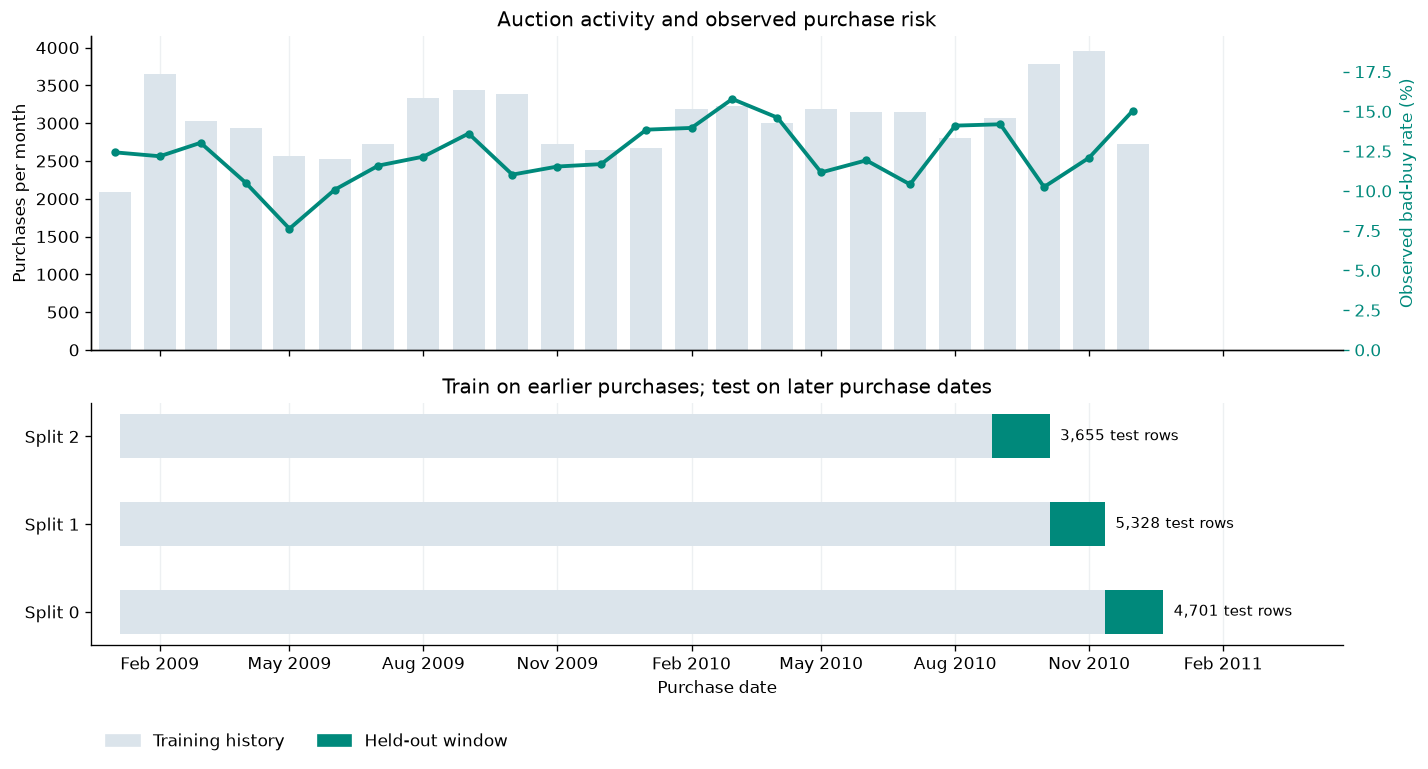

In [5]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

monthly = vehicles.assign(IsBadBuy=vehicles.IsBadBuy.astype(int)).set_index(
    "PurchDate"
).resample("MS").IsBadBuy.agg(["size", "mean"])
fig, (ax_volume, ax_split) = plt.subplots(
    2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]}
)
ax_volume.bar(monthly.index, monthly["size"], width=22, color="#dbe4eb")
ax_rate = ax_volume.twinx()
ax_rate.plot(monthly.index, monthly["mean"] * 100, color="#00897b",
             linewidth=2.3, marker="o", markersize=4)
ax_volume.set(ylabel="Purchases per month", title="Auction activity and observed purchase risk")
ax_rate.set_ylabel("Observed bad-buy rate (%)", color="#00897b")
ax_rate.tick_params(axis="y", colors="#00897b")
ax_rate.spines["top"].set_visible(False)
ax_rate.set_ylim(0, monthly["mean"].max() * 125)

for row, fold in enumerate([2, 1, 0]):
    train, test = splits["Vehicle purchases"][fold]
    train_start, train_end = vehicles.iloc[train].PurchDate.agg(["min", "max"])
    test_start, test_end = vehicles.iloc[test].PurchDate.agg(["min", "max"])
    ax_split.barh(row, (train_end - train_start).days + 1,
                  left=mdates.date2num(train_start), height=0.5, color="#dbe4eb")
    ax_split.barh(row, (test_end - test_start).days + 1,
                  left=mdates.date2num(test_start), height=0.5, color="#00897b")
    ax_split.annotate(f"{len(test):,} test rows", (mdates.date2num(test_end), row),
                      xytext=(7, 0), textcoords="offset points", va="center", fontsize=9)
ax_split.set(yticks=[0, 1, 2], yticklabels=["Split 2", "Split 1", "Split 0"],
             xlabel="Purchase date", title="Train on earlier purchases; test on later purchase dates")
ax_split.invert_yaxis()
ax_split.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_split.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_split.set_xlim(vehicles.PurchDate.min() - pd.Timedelta(days=20),
                  vehicles.PurchDate.max() + pd.Timedelta(days=115))
ax_split.legend(handles=[Patch(color="#dbe4eb", label="Training history"),
                         Patch(color="#00897b", label="Held-out window")],
                 loc="lower left", frameon=False, ncol=2, bbox_to_anchor=(0, -0.5))
for ax in (ax_volume, ax_split):
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#edf0f2")
fig.tight_layout()
plt.show()

## Compare the three models

Use the protein measurements as predictors and drop `MouseID`. For vehicles,
use purchase date only to define the split. Preserve missing values and encode
categorical columns with categories learned from the training rows; unseen
test categories become missing for every model.

Both TabPFN versions use four estimators and seed 42. XGBoost uses a fixed CPU
histogram configuration: 500 trees, depth 4, and learning rate 0.05. There is no
test-set tuning. This is a fresh cookbook comparison using simple preprocessing,
not a reproduction of Beyond Arena's feature generation or tuned baselines.

Show multiclass log-loss for mice and ROC AUC for vehicles, matching the
metric selected for Thinking below.

In [6]:
def prepare(frame, target, split_column, train, test):
    X_train = frame.iloc[train].drop(columns=[target, split_column]).copy()
    X_test = frame.iloc[test].drop(columns=[target, split_column]).copy()
    for column in X_train.select_dtypes(include=["category", "object", "string"]):
        categories = pd.Index(X_train[column].dropna().unique())
        X_train[column] = pd.Categorical(X_train[column], categories=categories)
        X_test[column] = pd.Categorical(X_test[column], categories=categories)
    encoder = LabelEncoder().fit(frame.iloc[train][target])
    return (X_train, X_test, encoder.transform(frame.iloc[train][target]),
            encoder.transform(frame.iloc[test][target]))

def compare(frame, target, split_column, task_splits, name, *,
            thinking_effort=None, thinking_metric=None):
    rows, predictions = [], {}
    for fold, (train, test) in enumerate(task_splits):
        X_train, X_test, y_train, y_test = prepare(frame, target, split_column, train, test)
        categorical = [X_train.columns.get_loc(c) for c in X_train.select_dtypes("category")]
        for model_name, version in [("TabPFN 3", ModelVersion.V3),
                                    ("TabPFN 3.5", ModelVersion.V3_5),
                                    ("XGBoost", None)]:
            if thinking_effort is not None and version is None:
                continue
            thinking = {}
            if thinking_effort is not None:
                model_name += " Thinking (high)"
                thinking = dict(thinking_effort=thinking_effort, thinking_metric=thinking_metric)
            model = (XGBClassifier(
                n_estimators=500, max_depth=4, learning_rate=0.05,
                tree_method="hist", device="cpu", enable_categorical=True,
                n_jobs=8, random_state=42,
            ) if version is None else TabPFNClassifier.create_default_for_version(
                version, n_estimators=4, random_state=42,
                categorical_features_indices=categorical, **thinking,
            ))
            started = time.perf_counter()
            model.fit(X_train, y_train)
            probability = model.predict_proba(X_test)
            seconds = time.perf_counter() - started
            assert np.isfinite(probability).all()
            assert np.allclose(probability.sum(axis=1), 1, atol=1e-5)
            assert np.array_equal(model.classes_, np.arange(len(np.unique(y_train))))
            rows.append({"Dataset": name, "Split": fold, "Model": model_name,
                         "Log-loss": log_loss(y_test, probability),
                         "Accuracy": accuracy_score(y_test, probability.argmax(axis=1)),
                         "ROC AUC": (roc_auc_score(y_test, probability[:, 1])
                                     if probability.shape[1] == 2 else np.nan),
                         "Seconds": seconds})
            predictions[f"{fold}_{model_name}"] = probability
            predictions[f"{fold}_y_test"] = y_test
            print(f"{name}, split {fold}: {model_name} finished in {seconds:.1f}s", flush=True)
    return pd.DataFrame(rows), predictions

### Unseen mice

Each test fold contains 24 animals, with 15 measurements per animal. Log-loss
is averaged over measurements; because each animal has the same number of
measurements, each animal has equal weight. The three folds are the evaluation
units, not 1,080 independent animals.

In [7]:
mice_results, mice_predictions = compare(
    mice, "class", "MouseID", splits["Mice proteins"], "Mice proteins"
)
display(mice_results[["Dataset", "Split", "Model", "Log-loss"]].round(4))

Mice proteins, split 0: restored TabPFN 3


Mice proteins, split 0: restored TabPFN 3.5


Mice proteins, split 0: restored XGBoost


Mice proteins, split 1: restored TabPFN 3


Mice proteins, split 1: restored TabPFN 3.5


Mice proteins, split 1: restored XGBoost


Mice proteins, split 2: restored TabPFN 3


Mice proteins, split 2: restored TabPFN 3.5


Mice proteins, split 2: restored XGBoost


,Dataset,Split,Model,Log-loss
0,Mice proteins,0,TabPFN 3,0.9846
1,Mice proteins,0,TabPFN 3.5,0.7673
2,Mice proteins,0,XGBoost,1.7500
3,Mice proteins,1,TabPFN 3,1.1757
4,Mice proteins,1,TabPFN 3.5,0.7599
5,Mice proteins,1,XGBoost,2.3767
6,Mice proteins,2,TabPFN 3,1.3678
7,Mice proteins,2,TabPFN 3.5,0.7504
8,Mice proteins,2,XGBoost,1.6433


### Future vehicle purchases

Fit on all available purchases before each forecast origin. The earlier
windows' observations can enter later training sets, as they would in a
rolling deployment. Each model uses the full training set and the full test
window; no random row split or subsampling is applied.

In [8]:
vehicle_results, vehicle_predictions = compare(
    vehicles, "IsBadBuy", "PurchDate", splits["Vehicle purchases"], "Vehicle purchases"
)
display(vehicle_results[["Dataset", "Split", "Model", "ROC AUC"]].round(4))

Vehicle purchases, split 0: restored TabPFN 3


Vehicle purchases, split 0: restored TabPFN 3.5


Vehicle purchases, split 0: restored XGBoost


Vehicle purchases, split 1: restored TabPFN 3


Vehicle purchases, split 1: restored TabPFN 3.5


Vehicle purchases, split 1: restored XGBoost


Vehicle purchases, split 2: restored TabPFN 3


Vehicle purchases, split 2: restored TabPFN 3.5


Vehicle purchases, split 2: restored XGBoost


,Dataset,Split,Model,ROC AUC
0,Vehicle purchases,0,TabPFN 3,0.8338
1,Vehicle purchases,0,TabPFN 3.5,0.8448
2,Vehicle purchases,0,XGBoost,0.8123
3,Vehicle purchases,1,TabPFN 3,0.7819
4,Vehicle purchases,1,TabPFN 3.5,0.7930
5,Vehicle purchases,1,XGBoost,0.7517
6,Vehicle purchases,2,TabPFN 3,0.7647
7,Vehicle purchases,2,TabPFN 3.5,0.7766
8,Vehicle purchases,2,XGBoost,0.7471


## Performance on grouped and temporal data

Bars show the mean across the three splits. Dots show the individual split
scores, making variation across mice folds and time windows visible. Lower
log-loss is better; higher ROC AUC is better. When scores are close, the chart
uses a clearly labeled zoomed axis. These dots are descriptive, not confidence
intervals.

Mice proteins: Log-loss


,Log-loss
Model,
TabPFN 3,1.1760
TabPFN 3.5,0.7592
XGBoost,1.9233


Vehicle purchases: ROC AUC


,ROC AUC
Model,
TabPFN 3,0.7935
TabPFN 3.5,0.8048
XGBoost,0.7704


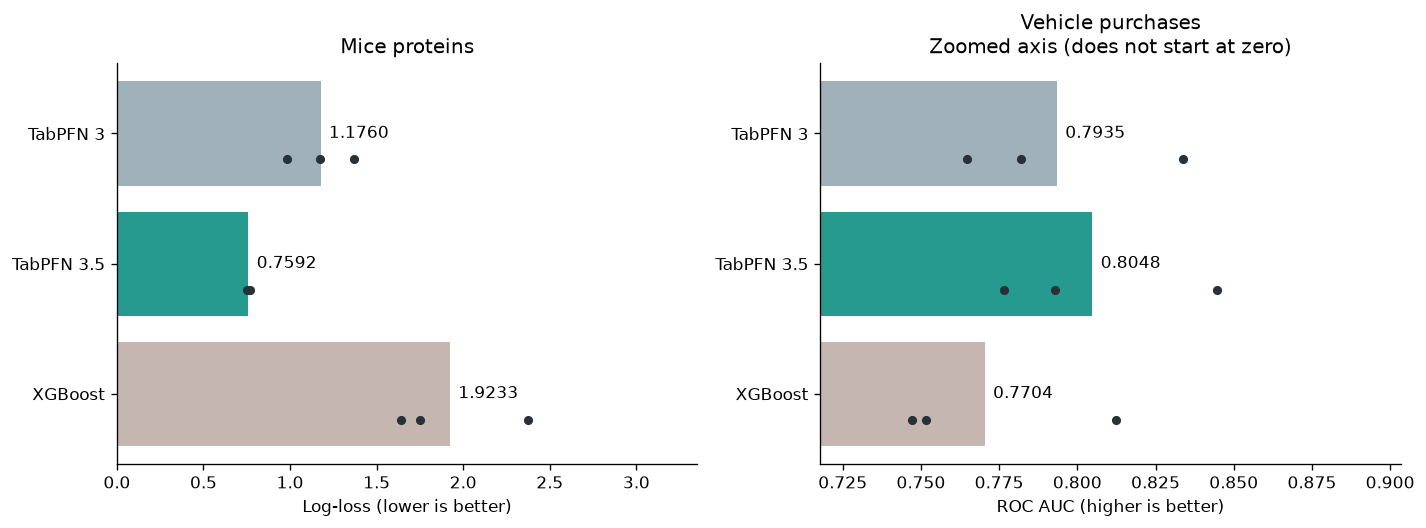

In [9]:
all_results = pd.concat([mice_results, vehicle_results], ignore_index=True)
summary = all_results.groupby(["Dataset", "Model"], sort=False)[
    ["Log-loss", "Accuracy", "ROC AUC", "Seconds"]
].mean()
for dataset, metric in [("Mice proteins", "Log-loss"), ("Vehicle purchases", "ROC AUC")]:
    print(f"{dataset}: {metric}")
    display(summary.loc[dataset, [metric]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (dataset, metric, direction) in zip(axes, [
    ("Mice proteins", "Log-loss", "lower"),
    ("Vehicle purchases", "ROC AUC", "higher"),
]):
    scores = all_results[all_results.Dataset == dataset].pivot(
        index="Model", columns="Split", values=metric
    ).reindex(["TabPFN 3", "TabPFN 3.5", "XGBoost"])
    bars = ax.barh(scores.index, scores.mean(axis=1),
                   color=["#90a4ae", "#00897b", "#bcaaa4"], alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=5)
    for position, (_, values) in enumerate(scores.iterrows()):
        ax.scatter(values, np.full(3, position + 0.20), color="#263238", s=20, zorder=3)
    low, high = scores.to_numpy().min(), scores.to_numpy().max()
    zoomed = low > 0 and high - low < 0.2 * high
    padding = max((high - low) * 0.3, high * 0.015, 0.001)
    ax.set_xlim(max(0, low - padding) if zoomed else 0, high + 2 * padding)
    ax.set_title(dataset + ("\nZoomed axis (does not start at zero)" if zoomed else ""))
    ax.set_xlabel(f"{metric} ({direction} is better)")
    ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Try high-effort Thinking

[Thinking mode](https://github.com/PriorLabs/tabpfn-client#thinking-mode) spends
more computation during `fit()` searching model configurations; prediction
still uses `predict_proba()`. Set `thinking_effort="high"` and choose the metric
before fitting: `log_loss` for the eight-class mice task, `roc_auc` for vehicle
risk ranking. The helper above forwards these settings to
`TabPFNClassifier.create_default_for_version()` for both versions.

Run the same three splits with the same training rows and preprocessing.
Only training data is passed to `fit()`; held-out labels are used for scoring.
Thinking's internal validation need not reproduce these group or time splits,
so the outer evaluation remains essential.

In [11]:
mice_thinking, mice_thinking_predictions = compare(
    mice, "class", "MouseID", splits["Mice proteins"], "Mice proteins",
    thinking_effort="high", thinking_metric="log_loss",
)
vehicle_thinking, vehicle_thinking_predictions = compare(
    vehicles, "IsBadBuy", "PurchDate", splits["Vehicle purchases"], "Vehicle purchases",
    thinking_effort="high", thinking_metric="roc_auc",
)

Mice proteins, split 0: restored TabPFN 3 Thinking (high)


Mice proteins, split 0: restored TabPFN 3.5 Thinking (high)


Mice proteins, split 1: restored TabPFN 3 Thinking (high)


Mice proteins, split 1: restored TabPFN 3.5 Thinking (high)


Mice proteins, split 2: restored TabPFN 3 Thinking (high)


...

Vehicle purchases, split 0: restored TabPFN 3.5 Thinking (high)


Vehicle purchases, split 1: restored TabPFN 3 Thinking (high)


Vehicle purchases, split 1: restored TabPFN 3.5 Thinking (high)


Vehicle purchases, split 2: restored TabPFN 3 Thinking (high)


Vehicle purchases, split 2: restored TabPFN 3.5 Thinking (high)


### Does Thinking improve held-out performance?

Compare each version with its standard counterpart using the metric selected
for Thinking. Bars show the three-split mean and dots show individual splits.
Each table shows only that task's selected metric. XGBoost remains the fixed
CPU baseline.

Mice proteins: Log-loss (lower is better)


,Log-loss
Model,
TabPFN 3,1.1760
TabPFN 3 Thinking (high),1.2056
TabPFN 3.5,0.7592
TabPFN 3.5 Thinking (high),0.7847
XGBoost,1.9233


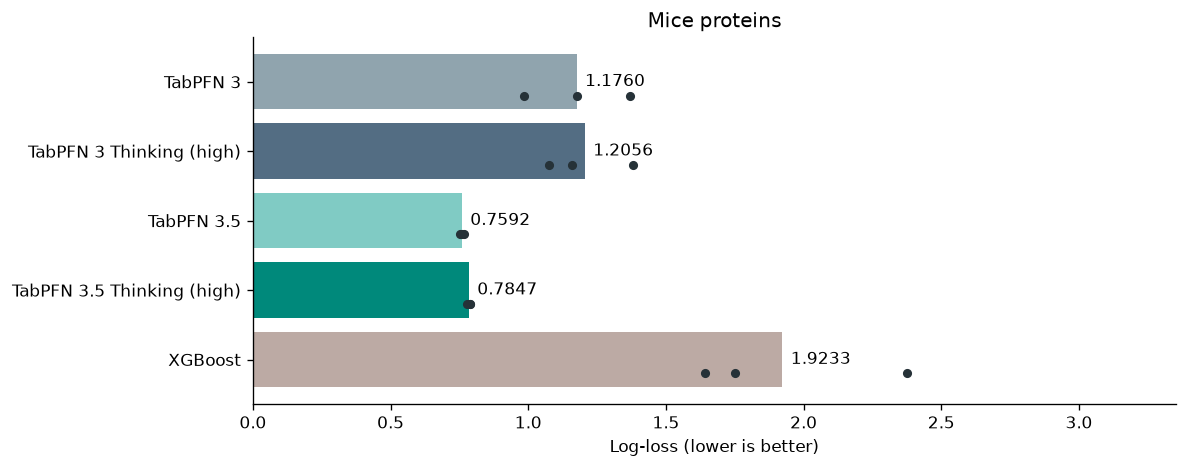

Vehicle purchases: ROC AUC (higher is better)


,ROC AUC
Model,
TabPFN 3,0.7935
TabPFN 3 Thinking (high),0.7944
TabPFN 3.5,0.8048
TabPFN 3.5 Thinking (high),0.8058
XGBoost,0.7704


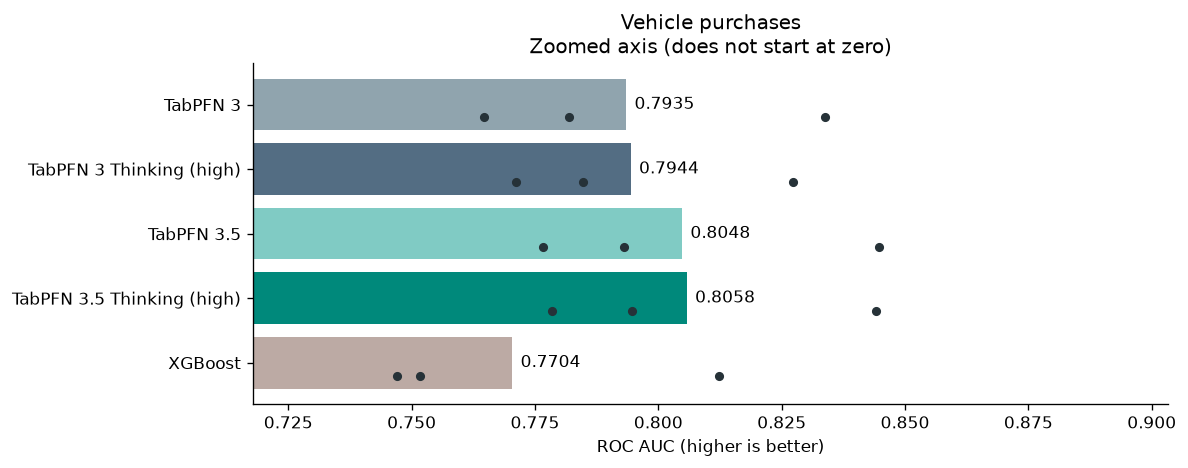

In [12]:
all_results = pd.concat([all_results, mice_thinking, vehicle_thinking], ignore_index=True)
summary = all_results.groupby(["Dataset", "Model"], sort=False)[
    ["Log-loss", "Accuracy", "ROC AUC", "Seconds"]
].mean()
model_order = ["TabPFN 3", "TabPFN 3 Thinking (high)",
               "TabPFN 3.5", "TabPFN 3.5 Thinking (high)", "XGBoost"]
for dataset, metric, direction in [
    ("Mice proteins", "Log-loss", "lower"),
    ("Vehicle purchases", "ROC AUC", "higher"),
]:
    print(f"{dataset}: {metric} ({direction} is better)")
    display(summary.loc[dataset, [metric]].reindex(model_order).round(4))
    scores = all_results[all_results.Dataset == dataset].pivot(
        index="Model", columns="Split", values=metric
    ).reindex(model_order)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(scores.index, scores.mean(axis=1),
                   color=["#90a4ae", "#536d83", "#80cbc4", "#00897b", "#bcaaa4"])
    ax.bar_label(bars, fmt="%.4f", padding=5)
    for position, (_, values) in enumerate(scores.iterrows()):
        ax.scatter(values, np.full(len(values), position + 0.20),
                   color="#263238", s=20, zorder=3)
    low, high = scores.to_numpy().min(), scores.to_numpy().max()
    zoomed = low > 0 and high - low < 0.2 * high
    padding = max((high - low) * 0.3, high * 0.015, 0.001)
    ax.set_xlim(max(0, low - padding) if zoomed else 0, high + 2 * padding)
    ax.set_title(dataset + ("\nZoomed axis (does not start at zero)" if zoomed else ""))
    ax.set_xlabel(f"{metric} ({direction} is better)")
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

## Reading the comparison

Standard TabPFN 3.5 outperformed standard TabPFN 3 on both tasks: mean mice
log-loss fell from **1.176 to 0.759**, and vehicle ROC AUC rose from **0.7935 to
0.8048**. It also outperformed this fixed XGBoost baseline on both metrics.

High-effort Thinking slightly worsened mean mice log-loss for both versions:
**1.176 to 1.206** for TabPFN 3 and **0.759 to 0.785** for 3.5. Vehicle ROC AUC
improved slightly on average, from **0.7935 to 0.7944** and **0.8048 to 0.8058**,
respectively. Thinking did not improve every vehicle window.

Choose a split that matches the next prediction: unseen subjects for grouped
data, later observations for temporal data. Keep that split fixed across
models, and inspect the per-split scores alongside their mean.

These two datasets were selected after inspecting earlier Beyond Arena
results. They are curated examples, not an unbiased benchmark of which model
wins across all datasets. The values above come from this notebook's fresh
runs with the same settings for each split.